# 🏡 Car Price Prediction - AI Model from Scratch

![SNOWFALL](Capture.PNG)


![SNOWFALL](Capture2.PNG)

### 🧰 Step 1: Setup and Import Libraries

In [1]:
import pandas as pd # for data preprocessing
import numpy as np # for data preprocessing
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization

# sklearn >> used for AI models training, testing, data scaling etc.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### 📦 Step 2: Load the Dataset

In [2]:
# url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
file_path = "pakwheels_used_car_data_v02.csv"
df = pd.read_csv(file_path)
df

,addref,city,assembly,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,7943732,Peshawar,NaN,Sedan,Toyota,Corolla,2013.0,1300.0,Manual,Petrol,Silver Metallic,Lahore,145000,2870000.0
1,7730314,Lahore,NaN,Sedan,Honda,City,2000.0,1300.0,Manual,Petrol,Blue,Lahore,230000,995000.0
2,7943737,Lahore,NaN,Sedan,Toyota,Yaris,2021.0,1300.0,Manual,Petrol,Super White,Punjab,60500,3585000.0
3,7943733,Lahore,NaN,Hatchback,Suzuki,Swift,2017.0,1300.0,Manual,Petrol,Grey,Islamabad,87000,2250000.0
4,7923484,Lahore,NaN,Sedan,Honda,Civic,2017.0,1800.0,Automatic,Petrol,Grey,Lahore,86000,4850000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77873,7775164,Daska,NaN,Sedan,Honda,Civic,2019.0,1800.0,Automatic,Petrol,Taffeta White,Islamabad,58000,5590000.0
77874,7772775,Abbottabad,Imported,Hatchback,Suzuki,Alto,2015.0,660.0,Automatic,Petrol,Brown,Islamabad,65000,2420000.0
77875,7773716,Faisalabad,Imported,Crossover,MG,HS,2021.0,1490.0,Automatic,Petrol,Arctic White,Un-Registered,5000,7500000.0
77876,7322377,Quetta,NaN,Sedan,Suzuki,Baleno,2005.0,1300.0,Manual,Petrol,Silver,Lahore,19000,1250000.0


In [3]:
df.head(4)

,addref,city,assembly,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,7943732,Peshawar,NaN,Sedan,Toyota,Corolla,2013.0,1300.0,Manual,Petrol,Silver Metallic,Lahore,145000,2870000.0
1,7730314,Lahore,NaN,Sedan,Honda,City,2000.0,1300.0,Manual,Petrol,Blue,Lahore,230000,995000.0
2,7943737,Lahore,NaN,Sedan,Toyota,Yaris,2021.0,1300.0,Manual,Petrol,Super White,Punjab,60500,3585000.0
3,7943733,Lahore,NaN,Hatchback,Suzuki,Swift,2017.0,1300.0,Manual,Petrol,Grey,Islamabad,87000,2250000.0


In [4]:
df.iloc[200:205] # index location

,addref,city,assembly,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
200,7943580,Islamabad,Imported,NaN,Nissan,Otti,2013.0,660.0,Automatic,Petrol,Grey,Lahore,65000,1650000.0
201,7941061,Lahore,NaN,Mini Van,Changan,Karvaan,2021.0,1000.0,Manual,Petrol,White,Lahore,10000,2575000.0
202,7903608,Islamabad,Imported,Sedan,Mercedes,Benz,2004.0,1800.0,Automatic,Petrol,Iridium Silver,Karachi,193270,2500000.0
203,7802530,Islamabad,NaN,Sedan,Honda,Civic,2013.0,1800.0,Manual,Petrol,Crystal Black,Karachi,87064,2095000.0
204,7943537,Islamabad,Imported,Hatchback,Toyota,Vitz,2010.0,1000.0,Automatic,Petrol,Silver,Lahore,125000,2120000.0


In [5]:
df.tail(4)

,addref,city,assembly,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
77874,7772775,Abbottabad,Imported,Hatchback,Suzuki,Alto,2015.0,660.0,Automatic,Petrol,Brown,Islamabad,65000,2420000.0
77875,7773716,Faisalabad,Imported,Crossover,MG,HS,2021.0,1490.0,Automatic,Petrol,Arctic White,Un-Registered,5000,7500000.0
77876,7322377,Quetta,NaN,Sedan,Suzuki,Baleno,2005.0,1300.0,Manual,Petrol,Silver,Lahore,19000,1250000.0
77877,7770898,Mandi,Imported,Sedan,Toyota,Corolla,1998.0,1600.0,Automatic,Petrol,Black,Lahore,12345,1150000.0


### 🔍 Step 3: Exploratory Data Analysis (EDA)

In [6]:
print(f"Rows and Columns: {df.shape}")
df.info() # null values, values types


Rows and Columns: (77878, 14)
<class 'pandas.DataFrame'>
RangeIndex: 77878 entries, 0 to 77877
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   addref        77878 non-null  int64  
 1   city          77878 non-null  str    
 2   assembly      24189 non-null  str    
 3   body          68974 non-null  str    
 4   make          77878 non-null  str    
 5   model         77878 non-null  str    
 6   year          73099 non-null  float64
 7   engine        77875 non-null  float64
 8   transmission  77878 non-null  str    
 9   fuel          76972 non-null  str    
 10  color         76398 non-null  str    
 11  registered    77878 non-null  str    
 12  mileage       77878 non-null  int64  
 13  price         77295 non-null  float64
dtypes: float64(3), int64(2), str(9)
memory usage: 8.3 MB


In [7]:
df.describe() # statistical features

,addref,year,engine,mileage,price
count,7.787800e+04,73099.000000,77875.000000,77878.000000,7.729500e+04
mean,7.809878e+06,2012.812610,1408.072550,91109.192750,3.883232e+06
std,2.599523e+05,7.516685,704.459947,89275.336173,5.759480e+06
min,2.748970e+05,1990.000000,3.000000,1.000000,1.100000e+05
25%,7.805760e+06,2007.000000,1000.000000,34000.000000,1.450000e+06
50%,7.865805e+06,2015.000000,1300.000000,80000.000000,2.700000e+06
75%,7.910334e+06,2019.000000,1600.000000,123456.000000,4.500000e+06
max,7.943741e+06,2022.000000,15000.000000,1000000.000000,5.290000e+08


In [8]:
# df.isnull()
# df.sum()

df.isnull().sum()

addref              0
city                0
assembly        53689
body             8904
make                0
model               0
year             4779
engine              3
transmission        0
fuel              906
color            1480
registered          0
mileage             0
price             583
dtype: int64

In [9]:
df.columns

Index(['addref', 'city', 'assembly', 'body', 'make', 'model', 'year', 'engine',
       'transmission', 'fuel', 'color', 'registered', 'mileage', 'price'],
      dtype='str')

In [10]:
df.columns

Index(['addref', 'city', 'assembly', 'body', 'make', 'model', 'year', 'engine',
       'transmission', 'fuel', 'color', 'registered', 'mileage', 'price'],
      dtype='str')

In [11]:
input_features = ['year', 'engine', 'mileage', 'price']
df = df[input_features]
df.head(4)

,year,engine,mileage,price
0,2013.0,1300.0,145000,2870000.0
1,2000.0,1300.0,230000,995000.0
2,2021.0,1300.0,60500,3585000.0
3,2017.0,1300.0,87000,2250000.0


In [12]:
df.isnull().sum()

year       4779
engine        3
mileage       0
price       583
dtype: int64

In [13]:
df.dropna(inplace=True)
df

,year,engine,mileage,price
0,2013.0,1300.0,145000,2870000.0
1,2000.0,1300.0,230000,995000.0
2,2021.0,1300.0,60500,3585000.0
3,2017.0,1300.0,87000,2250000.0
4,2017.0,1800.0,86000,4850000.0
...,...,...,...,...
77873,2019.0,1800.0,58000,5590000.0
77874,2015.0,660.0,65000,2420000.0
77875,2021.0,1490.0,5000,7500000.0
77876,2005.0,1300.0,19000,1250000.0


In [14]:
df.isnull().sum()

year       0
engine     0
mileage    0
price      0
dtype: int64

### 🛠️ Step 4: Data Preprocessing

In [15]:
# Separate features & label column
X = df.drop("price", axis=1) # features >> removing Target variable 'medv'
y = df["price"] #label >> select Target variable

scaler = StandardScaler() # initialize scaling model

'''
scaler.fit(X)
X_scaled = scaler.transform(X)

X_scaled = StandardScaler().fit(X).transform(X)
'''

X_scaled = scaler.fit_transform(X)

### 🔄 Step 5: Train-Test Split

In [16]:
# 20% data will be used as Testset and remaining 80% data will be used as Training set

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")


Train size: (58136, 3)
Test size: (14534, 3)


## ✅ Step 6: Train a Linear Regression Model

In [17]:
model = LinearRegression() # model intialize
model.fit(X_train, y_train) #Training


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 🔍 Step 7: Model Evaluation

In [18]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")


Mean Squared Error: 16985223557196.86
R^2 Score: 0.40


### 📈 Step 8: Visualizing Predictions

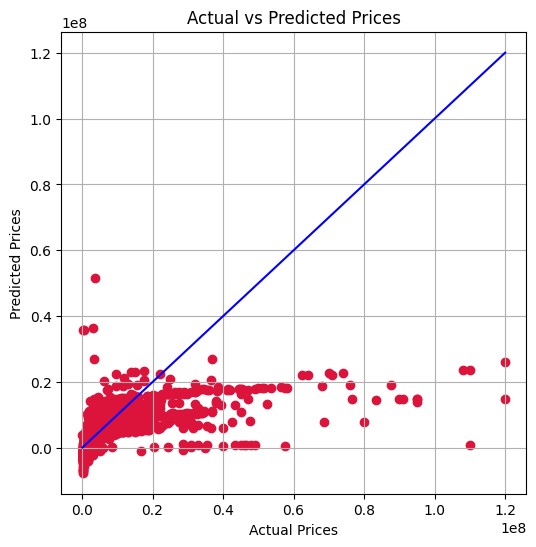

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, c='crimson')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='blue')
plt.grid()
plt.show()


## 🆕 Two New Models Added

| Model | Description |
|---|---|
| **Gradient Boosting Regressor** | Builds trees sequentially, each correcting the previous one. Usually very accurate. |
| **Support Vector Regressor (SVR)** | Finds the best-fit hyperplane within an epsilon margin. Works well on scaled data. |

### 🔧 Two New Hyperparameters Used

| Parameter | Applied To | Effect |
|---|---|---|
| `max_depth` | Decision Tree, Random Forest | Limits tree depth to avoid overfitting |
| `n_estimators` | Random Forest, Gradient Boosting | Number of trees — more trees = better generalization (but slower) |


## 🧠 Step 9: Train 3 More Regresion Models and Compare the performance

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# ✅ Two new hyperparameters added:
# 1. max_depth  - controls depth of tree-based models (prevents overfitting)
# 2. n_estimators - controls number of trees in ensemble models (more = better but slower)

max_depth = 10        # New Parameter 1: limit tree depth
n_estimators = 150    # New Parameter 2: number of trees in ensemble models

models = {
    "Linear Regression": model,  # already trained above
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=max_depth),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=n_estimators, max_depth=max_depth),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=n_estimators, max_depth=5),  # New Model 1
    "Support Vector Regressor (SVR)": SVR(kernel='rbf', C=100, epsilon=0.1),  # New Model 2
}

print(f"Hyperparameters used:")
print(f"  max_depth    = {max_depth}  (controls tree depth for DT & RF)")
print(f"  n_estimators = {n_estimators}  (number of trees for RF & GB)")
print()

for name, mdl in models.items():
    if name != "Linear Regression":
        mdl.fit(X_train, y_train)
    y_pred_i = mdl.predict(X_test)
    mse_i = mean_squared_error(y_test, y_pred_i)
    r2_i = r2_score(y_test, y_pred_i)
    print(f"{name:35s} - MSE: {mse_i:>15.2f},  R²: {r2_i:.4f}")


Hyperparameters used:
  max_depth    = 10  (controls tree depth for DT & RF)
  n_estimators = 150  (number of trees for RF & GB)

Linear Regression                   - MSE: 16985223557196.86,  R²: 0.3967
Decision Tree                       - MSE: 8525154820725.46,  R²: 0.6972
Random Forest                       - MSE: 6094082007038.74,  R²: 0.7835
K-Nearest Neighbors                 - MSE: 7006821437335.90,  R²: 0.7511
Gradient Boosting                   - MSE: 6280101552572.20,  R²: 0.7769


### 📊 Compare Models

In [1]:
  # =======================================
# Compare All Models - Simple & Clean
# =======================================

# Step 1: Collect results from all models
results = []

for name, mdl in models.items():
    y_pred_i = mdl.predict(X_test)          # make predictions
    r2_i     = r2_score(y_test, y_pred_i)   # R2 score (higher = better)
    mse_i    = mean_squared_error(y_test, y_pred_i)  # MSE (lower = better)
    results.append((name, r2_i, mse_i))     # save results

# Step 2: Sort by best R2 score
results.sort(key=lambda x: x[1], reverse=True)

# Step 3: Separate names and scores for the chart
model_names = [r[0] for r in results]
r2_scores   = [r[1] for r in results]

# Step 4: Draw bar chart
plt.figure(figsize=(12, 5))
plt.bar(model_names, r2_scores, color='steelblue')
plt.title("R2 Score Comparison - All Models")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Step 5: Print ranking table
print("Model Ranking:")
print("-" * 60)
for i, (name, r2_i, mse_i) in enumerate(results, 1):
    print(f"{i}. {name:<35} R2: {r2_i:.2f}   MSE: {mse_i:.0f}")

NameError: name 'models' is not defined

## Test the AI model prediction on a sample data

In [ ]:
# Let take a sample
X_test[101]

In [ ]:
y_test.iloc[0]

In [ ]:
# let's check actual price for this sample
y_test.iloc[101]

In [ ]:
# Take a sample
sample_X = X_test[0]   # or .iloc[0] if pandas

# Reshape if needed
sample_X = sample_X.reshape(1, -1)

# Predict
sample_y_pred = model.predict(sample_X)

# Print results
print(f"Actual value: {y_test.iloc[0]:.2f}")
print(f"Prediction: {sample_y_pred[0]:.2f}")